## iris dataset으로 다항분류 후 모델 성능 확인: ROC 커브 까지

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn. preprocessing import OneHotEncoder, StandardScaler

In [12]:
iris = load_iris()
print(iris.keys())
x = iris.data
y = iris.target
print(x[:2])
print(y[:2])
print(set(y))

names = iris.target_names
print(names)
feature_names = iris.feature_names
print(feature_names)

onehot = OneHotEncoder(categories='auto')   # to_categorical, numpy: np.eye(), pd.get_dummies
print(y.shape)  # (150,)
y = onehot.fit_transform(y[:, np.newaxis]).toarray()
print(y.shape)
print(y[:2])

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]]
[0 0]
{0, 1, 2}
['setosa' 'versicolor' 'virginica']
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
(150,)
(150, 3)
[[1. 0. 0.]
 [1. 0. 0.]]


## label: onehot

In [13]:
# feature: 표준화 
print(x[:2])
scaler = StandardScaler()
x_scale = scaler.fit_transform(x)
print(x_scale[:2])

x_train, x_test, y_train, y_test = train_test_split(x_scale, y, test_size=0.3, random_state=1)

n_features = x_train.shape[1]
n_classes = y_train.shape[1]  # 클래스 수는 y_train의 열 개수
print(n_features, n_classes)

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]]
[[-0.90068117  1.01900435 -1.34022653 -1.3154443 ]
 [-1.14301691 -0.13197948 -1.34022653 -1.3154443 ]]
4 3


In [14]:
from matplotlib import units
from numpy import shape
from sklearn import metrics
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

def create_model_func(input_dim, out_dim, out_nodes, n, model_name='model'):
    # print(input_dim, out_dim, out_nodes, n, model_name)
    def create_model():
        model = Sequential(name=model_name)
        model.add(Input(shape=(input_dim,)))
        for _ in range(n):
            model.add(Dense(units=out_nodes, activation='relu'))
            model.add(Dense(units=out_dim, activation='softmax'))
            model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['acc'])
        return model
    return create_model     # closure

models = [create_model_func(n_features, n_classes, 10, n, 'model_{}'.format(n)) for n in range(1, 4)]
print(len(models))

for create_model in models:
    print()
    create_model().summary()

3

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_24 (Dense)            (None, 10)                50        
                                                                 
 dense_25 (Dense)            (None, 3)                 33        
                                                                 
Total params: 83
Trainable params: 83
Non-trainable params: 0
_________________________________________________________________

Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_26 (Dense)            (None, 10)                50        
                                                                 
 dense_27 (Dense)            (None, 3)                 33        
                                                                 
 dense_28 (Dense)            (None, 10)   

In [15]:
from tabnanny import verbose


history_dict = {}
for create_model in models:
    model = create_model()
    print('모델명: ', model.name)
    historys =  model.fit(x_train, y_train, batch_size=8, epochs=50, verbose=0, validation_split=0.2)
    score = model.evaluate(x_test, y_test, verbose=0)
    print('test dataset loss: ', score[0])
    print('test dataset acc: ', score[1])
    history_dict[model.name] = [historys, model]

print(history_dict)

모델명:  model_1
test dataset loss:  0.4292752146720886
test dataset acc:  0.7555555701255798
모델명:  model_2
test dataset loss:  0.5600353479385376
test dataset acc:  0.6000000238418579
모델명:  model_3
test dataset loss:  0.5508019328117371
test dataset acc:  0.6000000238418579
{'model_1': [<keras.callbacks.History object at 0x00000241BCE76BC0>, <keras.engine.sequential.Sequential object at 0x00000241B998FB80>], 'model_2': [<keras.callbacks.History object at 0x00000241BCFAC520>, <keras.engine.sequential.Sequential object at 0x00000241B9675CF0>], 'model_3': [<keras.callbacks.History object at 0x00000241BD187520>, <keras.engine.sequential.Sequential object at 0x00000241BCFC9150>]}


h_d:  [0.380952388048172, 0.380952388048172, 0.380952388048172, 0.3928571343421936, 0.3928571343421936, 0.3928571343421936, 0.4047619104385376, 0.4642857015132904, 0.5, 0.523809552192688, 0.6071428656578064, 0.6666666865348816, 0.726190447807312, 0.738095223903656, 0.738095223903656, 0.75, 0.773809552192688, 0.7857142686843872, 0.8095238208770752, 0.8214285969734192, 0.8333333134651184, 0.8452380895614624, 0.8452380895614624, 0.8452380895614624, 0.8452380895614624, 0.8571428656578064, 0.8571428656578064, 0.8571428656578064, 0.8571428656578064, 0.8571428656578064, 0.8809523582458496, 0.8809523582458496, 0.8809523582458496, 0.8809523582458496, 0.8809523582458496, 0.8809523582458496, 0.8690476417541504, 0.8690476417541504, 0.8809523582458496, 0.8809523582458496, 0.8809523582458496, 0.8809523582458496, 0.8928571343421936, 0.8928571343421936, 0.8928571343421936, 0.8928571343421936, 0.8928571343421936, 0.8928571343421936, 0.8928571343421936, 0.8928571343421936]
h_d:  [0.3333333432674408, 0.3

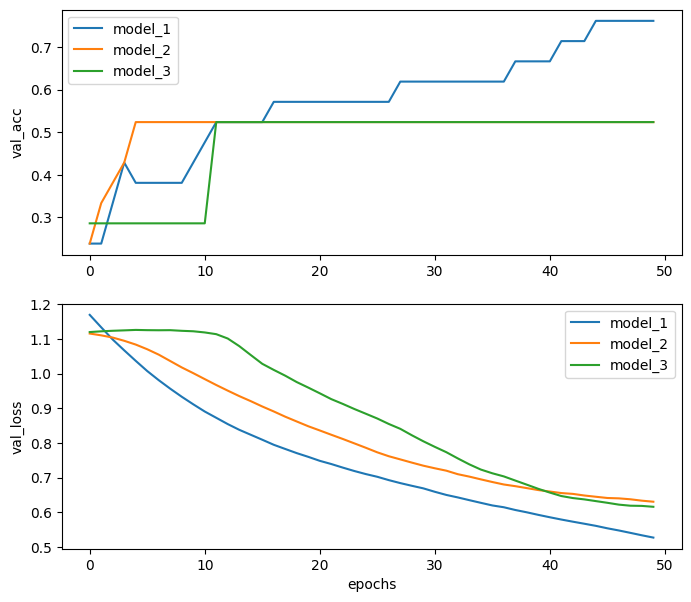

In [16]:
from cProfile import label


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 7))

for model_name in history_dict:
    print('h_d: ', history_dict[model_name][0].history['acc'])
    val_acc = history_dict[model_name][0].history['val_acc']
    val_loss = history_dict[model_name][0].history['val_loss']
    ax1.plot(val_acc, label = model_name)
    ax2.plot(val_loss, label = model_name)
    ax1.set_ylabel('val_acc')
    ax2.set_ylabel('val_loss')
    ax2.set_xlabel('epochs')
    ax1.legend()
    ax2.legend()
plt.show()

## ROC Curve: 분류기에 대한 성능 평가 방법 중 하나

2/2 [==============================] - 0s 5ms/step


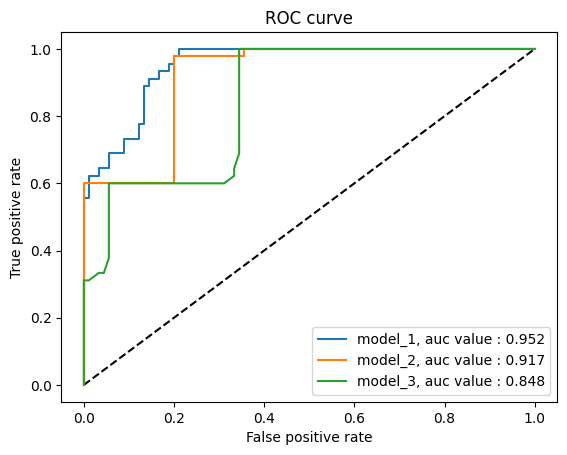

In [19]:
from sklearn.metrics import roc_curve, auc


plt.figure()
plt.plot([0, 1], [0, 1], 'k--')

for model_name in history_dict:
    model = history_dict[model_name][1]
    y_pred = model.predict(x_test)
    fpr, tpr, _ = roc_curve(y_test.ravel(), y_pred.ravel())
    plt.plot(fpr, tpr, label='{}, auc value : {:.3f}'.format(model_name, auc(fpr, tpr)))

plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curve')
plt.legend()
plt.show()
